# EuroSAT baseline classifier

Pipeline sanity-check: train/val split, data loading, training loop, metrics.

Note: EuroSAT gives one label per whole image (classification), not pixel masks. This is *not* the final segmentation model — it just proves the training pipeline works before moving to real Sentinel-2 + ESA WorldCover segmentation data.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import torch
from torch import nn

from helpers.dataloaders import load_eurosat_data, build_dataloaders
from models.resnet18_classifier_builder import build_resnet18_classifier
from training.engine import Engine
from training.evaluate import evaluate_classifier, draw_confusion_matrix


DATA_DIR = Path.cwd().parent / "data"

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## 1/ Load EuroSat data (preprocessed with a transform)


In [2]:

full_dataset = load_eurosat_data()

classes = full_dataset.classes

print(f"{len(full_dataset)} images, {len(classes)} classes: {classes}")

27000 images, 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


##  2/ Split the dataset into training, validation and test DataLoader


In [3]:

BATCH_SIZE = 64
SEED_NUM = 42
train_loader, val_loader, test_loader = build_dataloaders(full_dataset, BATCH_SIZE, 0.7, 0.15, SEED_NUM)


##  3/ Load the pretrained ResNet18 model and modify the final fully connected layer to match the number of classes in EuroSAT
#### TODO : maybe use a different model, like EfficientNet, or a custom CNN, or a ViT (Vision Transformer) model


In [4]:
# 3/ Load the pretrained ResNet18 model and modify the final fully connected layer to match the number of classes in EuroSAT
# TODO : maybe use a different model, like EfficientNet, or a custom CNN, or a ViT (Vision Transformer) model

model_resnet18 = build_resnet18_classifier(num_classes=len(classes), device=device)

# 7/ Define the loss function
# CrossEntropyLoss combine en une seule opération LogSoftmax + NLLLoss (Negative Log-Likelihood Loss)
# -> parfait pour classification multi-classe, mono-label (1 image = 1 classe)
#
# Alternatives :
# - nn.NLLLoss                          -> meme chose mais il faut appliquer soi-meme LogSoftmax avant
# - nn.BCEWithLogitsLoss                -> si multi-label (une image pourrait avoir plusieurs classes en meme temps)
# - CrossEntropyLoss(weight=...)        -> si les classes etaient desequilibrees (pondere chaque classe)
# - CrossEntropyLoss(label_smoothing=.1)-> reduit la sur-confiance du modele, ameliore la generalisation
# - Focal Loss (pas native PyTorch)     -> utile si classes rares/difficiles (frequent en teledetection)
# - Dice Loss / Dice+CE                 -> pour la future segmentation d'images (ex: segmenter les routes, les batiments, etc.)
loss_fn = nn.CrossEntropyLoss()

# NB : l'optimiseur n'est plus défini ici, chaque phase (freeze-first) a le sien -> voir cellule d'entraînement

## 4/ Train the model


### 4.1/ Train on Resnet18 in 2 phases (freeze-first)

Params config:
```json
{
    build_model: build_resnet18_classifier,
    loss_fn: CrossEntropyLoss(),
    train: "freeze-first",
    nb_epoch_1: 6,
    lr_1: 1e-3,
    nb_epoch_2: 9,
    lr_2: 1e-5,
    nb_epoch_total: 15,
}
```

In [ ]:
# Run the model Resnet18 train - freeze-first transfer learning (2 phases)

from models.resnet18_classifier_builder import freeze_backbone, unfreeze_backbone

EPOCHS_PHASE1 = 6  # backbone gelé, seule la tête s'entraîne
EPOCHS_PHASE2 = 9  # backbone dégelé, tout le réseau s'affine à un lr plus faible

# Phase 1 : backbone gelé, seule la tête (fc) s'entraîne
# lr plus élevé car la tête est initialisée aléatoirement et doit apprendre vite
freeze_backbone(model_resnet18)
optimizer_phase1 = torch.optim.Adam(model_resnet18.fc.parameters(), lr=1e-3)
engine_phase1 = Engine(device, loss_fn, optimizer_phase1)
#engine_phase1.display_info()
history_phase1 = engine_phase1.train_model(model_resnet18, train_loader, val_loader, EPOCHS_PHASE1)

# Phase 2 : backbone dégelé, tout le réseau s'affine à un lr plus faible
# lr faible pour ne pas détruire les features pré-entraînées pendant le fine-tuning
unfreeze_backbone(model_resnet18)
optimizer_phase2 = torch.optim.Adam(model_resnet18.parameters(), lr=1e-5)
engine_phase2 = Engine(device, loss_fn, optimizer_phase2)
#engine_phase2.display_info()
history_phase2 = engine_phase2.train_model(model_resnet18, train_loader, val_loader, EPOCHS_PHASE2)

# Fusion des historiques des deux phases pour le plot ci-dessous
history = {key: history_phase1[key] + history_phase2[key] for key in history_phase1}

Epoch 1/6 - Train Loss: 0.8810, Train Acc: 0.7366 - Val Loss: 0.5635, Val Acc: 0.8279
Epoch 2/6 - Train Loss: 0.5425, Train Acc: 0.8312 - Val Loss: 0.4848, Val Acc: 0.8533
Epoch 3/6 - Train Loss: 0.4850, Train Acc: 0.8449 - Val Loss: 0.4579, Val Acc: 0.8548
Epoch 4/6 - Train Loss: 0.4568, Train Acc: 0.8549 - Val Loss: 0.4452, Val Acc: 0.8570
Epoch 5/6 - Train Loss: 0.4452, Train Acc: 0.8552 - Val Loss: 0.4712, Val Acc: 0.8457


### 4.2 Compare with Train on Resnet18 in 1 phases: baseline single-phase (sans freeze), même nombre total d'epochs

Params config:
```json
{
    build_model: build_resnet18_classifier,
    loss_fn: CrossEntropyLoss(),
    nb_epoch_1: 15,
    lr_1: 1e-4,
    nb_epoch_total: 15,
}

In [ ]:
# Baseline (comparaison) : fine-tuning single-phase, tout le réseau entraîné dès le départ, sans freeze
# Nouveau modèle indépendant (mêmes poids ImageNet de départ) pour ne pas repartir des poids déjà affinés par le freeze-first

model_baseline = build_resnet18_classifier(num_classes=len(classes), device=device)

EPOCHS_BASELINE = EPOCHS_PHASE1 + EPOCHS_PHASE2  # même nombre total d'epochs que le freeze-first, pour comparer à effort égal

optimizer_baseline = torch.optim.Adam(model_baseline.parameters(), lr=1e-4)
engine_baseline = Engine(device, loss_fn, optimizer_baseline)
#engine_baseline.display_info()

history_baseline = engine_baseline.train_model(model_baseline, train_loader, val_loader, EPOCHS_BASELINE)

device: mps, loss_fn: CrossEntropyLoss(), optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Epoch 1/15 - Train Loss: 0.3223, Train Acc: 0.8972 - Val Loss: 0.1201, Val Acc: 0.9635
Epoch 2/15 - Train Loss: 0.0724, Train Acc: 0.9764 - Val Loss: 0.1096, Val Acc: 0.9640
Epoch 3/15 - Train Loss: 0.0482, Train Acc: 0.9848 - Val Loss: 0.1194, Val Acc: 0.9632
Epoch 4/15 - Train Loss: 0.0332, Train Acc: 0.9897 - Val Loss: 0.1189, Val Acc: 0.9640
Epoch 5/15 - Train Loss: 0.0300, Train Acc: 0.9905 - Val Loss: 0.1353, Val Acc: 0.9580
Epoch 6/15 - Train Loss: 0.0295, Train Acc: 0.9900 - Val Loss: 0.1202, Val Acc: 0.9674
Epoch 7/15 - Train Loss: 0.0229, Train Acc: 0.9928 - Val Loss: 0.1258, Val Acc: 0.9677
Epoch 8/15 - Train Loss: 0.0249, Train Acc: 0.9916 - Val Loss: 0.1337, Val Acc: 0.

### 4.3 Compare using another loss function (label_smoothing=0.1)

Params config:
```json
{
    build_model: build_resnet18_classifier,
    loss_fn: CrossEntropyLoss(label_smoothing=0.1),
    nb_epoch_1: 15,
    lr_1: 1e-4,
    nb_epoch_total: 15,
}

In [ ]:
# Comparaison loss : CrossEntropyLoss avec label smoothing (réduit la sur-confiance, régularise)
# Même modèle (ResNet18) et même stratégie (single-phase) que le baseline pour isoler l'effet de la loss

model_label_smoothing = build_resnet18_classifier(num_classes=len(classes), device=device)
loss_fn_label_smoothing = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_label_smoothing = torch.optim.Adam(model_label_smoothing.parameters(), lr=1e-4)
engine_label_smoothing = Engine(device, loss_fn_label_smoothing, optimizer_label_smoothing)
# engine_label_smoothing.display_info()

history_label_smoothing = engine_label_smoothing.train_model(model_label_smoothing, train_loader, val_loader, EPOCHS_BASELINE)

device: mps, loss_fn: CrossEntropyLoss(), optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Epoch 1/15 - Train Loss: 0.7817, Train Acc: 0.8968 - Val Loss: 0.6081, Val Acc: 0.9669
Epoch 2/15 - Train Loss: 0.5779, Train Acc: 0.9775 - Val Loss: 0.5899, Val Acc: 0.9679
Epoch 3/15 - Train Loss: 0.5486, Train Acc: 0.9888 - Val Loss: 0.5761, Val Acc: 0.9728
Epoch 4/15 - Train Loss: 0.5299, Train Acc: 0.9947 - Val Loss: 0.5732, Val Acc: 0.9699
Epoch 5/15 - Train Loss: 0.5244, Train Acc: 0.9952 - Val Loss: 0.5697, Val Acc: 0.9733
Epoch 6/15 - Train Loss: 0.5203, Train Acc: 0.9960 - Val Loss: 0.5798, Val Acc: 0.9674
Epoch 7/15 - Train Loss: 0.5189, Train Acc: 0.9967 - Val Loss: 0.5792, Val Acc: 0.9706
Epoch 8/15 - Train Loss: 0.5162, Train Acc: 0.9971 - Val Loss: 0.5766, Val Acc: 0.

### 4.3/ Compare using another model: EfficientNet-B0, 2 phases stratégy (freeze-first) but with more epochs
Params config:
```json
{
    build_model: build_efficientnet_b0_classifier,
    loss_fn: CrossEntropyLoss(),
    train: "freeze-first",
    nb_epoch_1: 10,
    lr_1: 1e-3,
    nb_epoch_2: 15,
    lr_2: 1e-5,
    nb_epoch_total: 25,
}


In [ ]:
# Comparaison modèle : EfficientNet-B0 (autre famille CNN, meilleur ratio précision/paramètres que ResNet18)
# Même stratégie freeze-first (2 phases) que le run ResNet18 pour isoler l'effet du choix d'architecture

from models.efficientnet_b0_classifier_builder import build_efficientnet_b0_classifier, freeze_backbone, unfreeze_backbone

EPOCHS_PHASE1 = 10  # backbone gelé, seule la tête s'entraîne
EPOCHS_PHASE2 = 15  # backbone dégelé, tout le réseau s entraine à un lr plus faible

model_efficientnet = build_efficientnet_b0_classifier(num_classes=len(classes), device=device)

# Phase 1 : backbone gelé, seule la tête (classifier) s'entraîne
print("Phase 1 : backbone gelé, seule la tête (classifier) s'entraîne")
freeze_backbone(model_efficientnet)
optimizer_efficientnet_phase1 = torch.optim.Adam(model_efficientnet.classifier.parameters(), lr=1e-3)
engine_efficientnet_phase1 = Engine(device, loss_fn, optimizer_efficientnet_phase1)
#engine_efficientnet_phase1.display_info()
history_efficientnet_phase1 = engine_efficientnet_phase1.train_model(model_efficientnet, train_loader, val_loader, EPOCHS_PHASE1)

# Phase 2 : backbone dégelé, tout le réseau s'affine à un lr plus faible
print("Phase 2 : backbone dégelé, tout le réseau s'affine à un lr plus faible")
unfreeze_backbone(model_efficientnet)
optimizer_efficientnet_phase2 = torch.optim.Adam(model_efficientnet.parameters(), lr=1e-5)
engine_efficientnet_phase2 = Engine(device, loss_fn, optimizer_efficientnet_phase2)
#engine_efficientnet_phase2.display_info()
history_efficientnet_phase2 = engine_efficientnet_phase2.train_model(model_efficientnet, train_loader, val_loader, EPOCHS_PHASE2)

# Fusion des historiques des deux phases pour le plot
history_efficientnet = {key: history_efficientnet_phase1[key] + history_efficientnet_phase2[key] for key in history_efficientnet_phase1}

Phase 1 : backbone gelé, seule la tête (classifier) s'entraîne
Epoch 1/10 - Train Loss: 0.9031, Train Acc: 0.7218 - Val Loss: 0.6147, Val Acc: 0.8042
Epoch 2/10 - Train Loss: 0.6297, Train Acc: 0.7918 - Val Loss: 0.5672, Val Acc: 0.8148
Epoch 3/10 - Train Loss: 0.6025, Train Acc: 0.7976 - Val Loss: 0.5755, Val Acc: 0.8175
Epoch 4/10 - Train Loss: 0.6013, Train Acc: 0.8020 - Val Loss: 0.6545, Val Acc: 0.8148
Epoch 5/10 - Train Loss: 0.5869, Train Acc: 0.8028 - Val Loss: 0.5380, Val Acc: 0.8220
Epoch 6/10 - Train Loss: 0.5889, Train Acc: 0.8046 - Val Loss: 0.5355, Val Acc: 0.8230
Epoch 7/10 - Train Loss: 0.5877, Train Acc: 0.8010 - Val Loss: 0.5283, Val Acc: 0.8237
Epoch 8/10 - Train Loss: 0.5852, Train Acc: 0.8020 - Val Loss: 0.5345, Val Acc: 0.8205
Epoch 9/10 - Train Loss: 0.5903, Train Acc: 0.8042 - Val Loss: 0.5207, Val Acc: 0.8247
Epoch 10/10 - Train Loss: 0.5680, Train Acc: 0.8148 - Val Loss: 0.5228, Val Acc: 0.8242
Phase 2 : backbone dégelé, tout le réseau s'affine à un lr plus fa

### 4.4 Show loss function and accuracy curves for each 4 approches to compare results

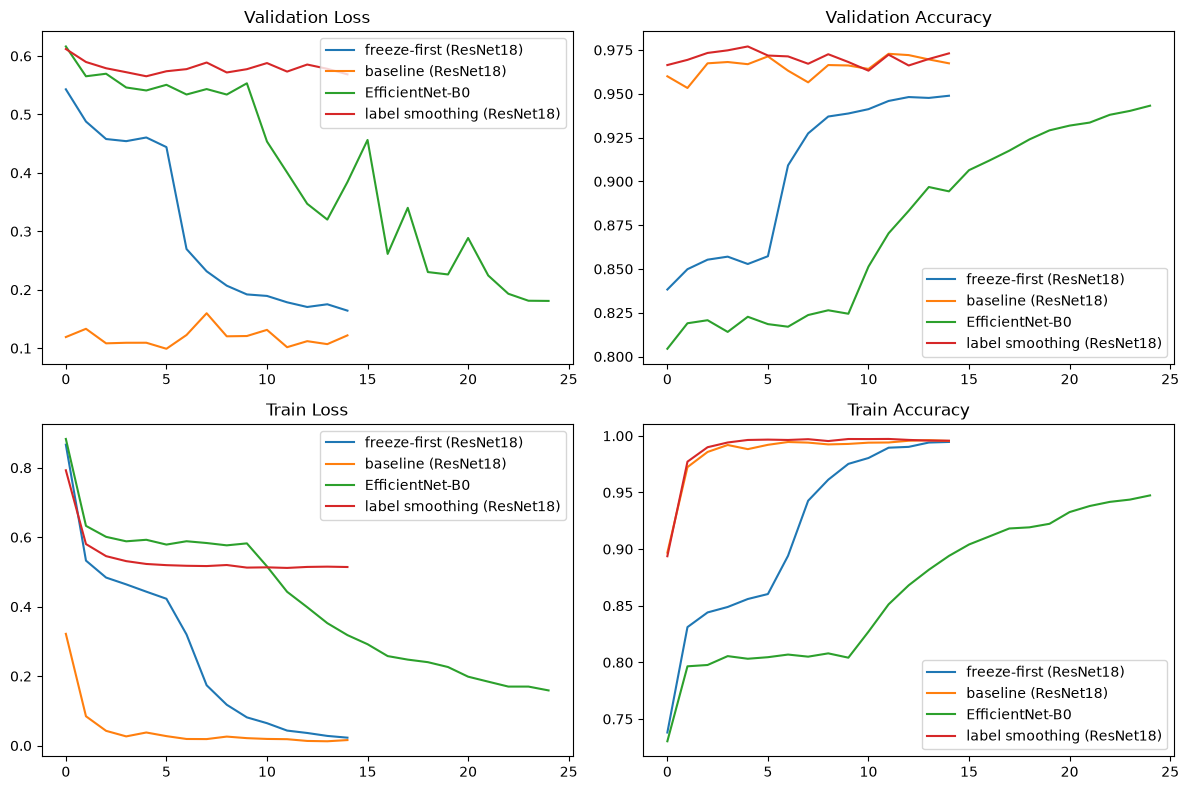

In [10]:
# 10/ Plot the training and validation loss and accuracy curves — comparaison des 4 approches
import matplotlib.pyplot as plt

runs = {
    "freeze-first (ResNet18)": history,
    "baseline (ResNet18)": history_baseline,
    "EfficientNet-B0": history_efficientnet,
    "label smoothing (ResNet18)": history_label_smoothing,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for label, h in runs.items():
    axes[0].plot(h["val_loss"], label=label)
    axes[1].plot(h["val_acc"], label=label)
    axes[2].plot(h["train_loss"], label=label)
    axes[3].plot(h["train_acc"], label=label)

axes[0].set_title("Validation Loss")
axes[0].legend()

axes[1].set_title("Validation Accuracy")
axes[1].legend()

axes[2].set_title("Train Loss")
axes[2].legend()

axes[3].set_title("Train Accuracy")
axes[3].legend()

plt.tight_layout()
plt.show()

## 5/ Test set evaluation

#### Evaluation of the trained model on the "test" split set [backbone freezed + unfreezed] for the 4 approches



                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.94      0.95       472
              Forest       0.98      0.98      0.98       442
HerbaceousVegetation       0.93      0.95      0.94       458
             Highway       0.89      0.91      0.90       391
          Industrial       0.96      0.96      0.96       378
             Pasture       0.93      0.93      0.93       299
       PermanentCrop       0.93      0.90      0.92       379
         Residential       0.97      0.98      0.98       450
               River       0.92      0.91      0.91       375
             SeaLake       0.97      0.99      0.98       406

            accuracy                           0.94      4050
           macro avg       0.94      0.94      0.94      4050
        weighted avg       0.94      0.94      0.94      4050



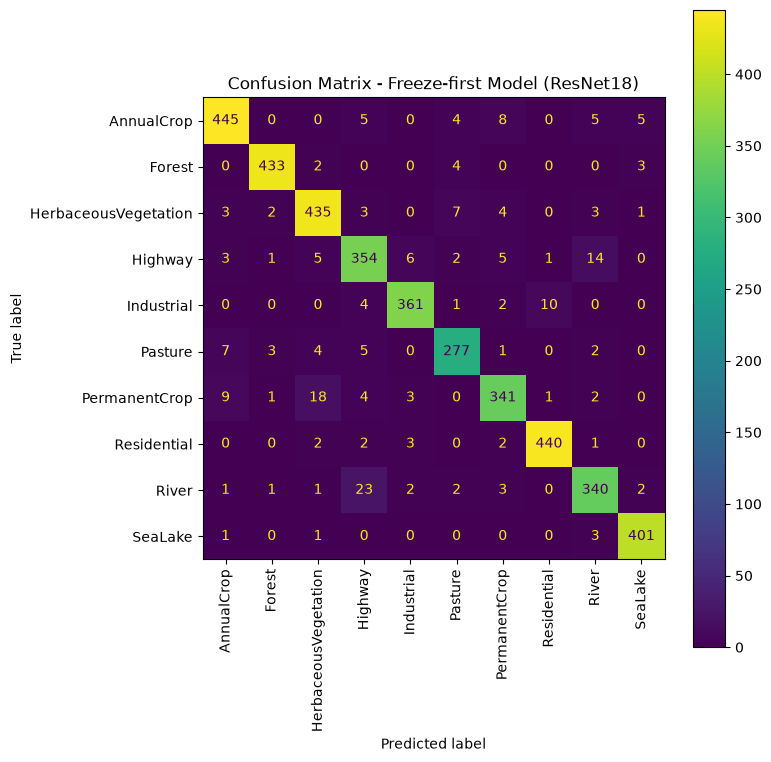

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.93      0.96       472
              Forest       0.98      0.98      0.98       442
HerbaceousVegetation       0.96      0.97      0.96       458
             Highway       0.98      0.96      0.97       391
          Industrial       0.99      0.96      0.97       378
             Pasture       0.96      0.96      0.96       299
       PermanentCrop       0.92      0.97      0.95       379
         Residential       0.97      0.99      0.98       450
               River       0.97      0.95      0.96       375
             SeaLake       0.97      1.00      0.98       406

            accuracy                           0.97      4050
           macro avg       0.97      0.97      0.97      4050
        weighted avg       0.97      0.97      0.97      4050



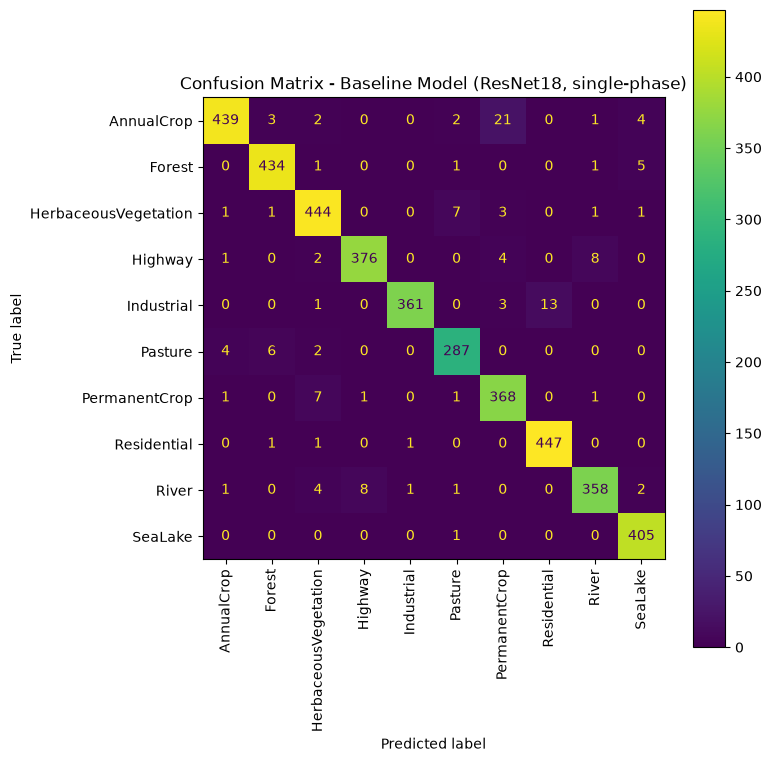

                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.95      0.95       472
              Forest       0.97      0.98      0.98       442
HerbaceousVegetation       0.89      0.95      0.92       458
             Highway       0.93      0.93      0.93       391
          Industrial       0.97      0.95      0.96       378
             Pasture       0.93      0.93      0.93       299
       PermanentCrop       0.93      0.89      0.91       379
         Residential       0.97      0.97      0.97       450
               River       0.94      0.94      0.94       375
             SeaLake       0.99      0.95      0.97       406

            accuracy                           0.95      4050
           macro avg       0.95      0.94      0.94      4050
        weighted avg       0.95      0.95      0.95      4050



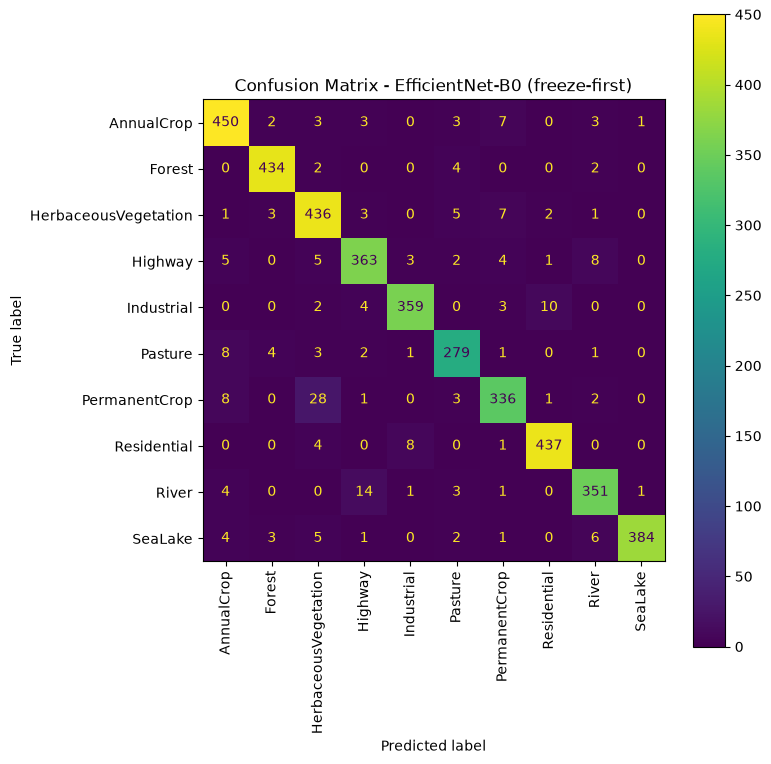

                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.97      0.97       472
              Forest       0.98      0.99      0.99       442
HerbaceousVegetation       0.97      0.97      0.97       458
             Highway       0.98      0.97      0.97       391
          Industrial       0.98      0.99      0.98       378
             Pasture       0.97      0.96      0.97       299
       PermanentCrop       0.98      0.94      0.96       379
         Residential       0.99      0.99      0.99       450
               River       0.97      0.96      0.96       375
             SeaLake       0.96      1.00      0.98       406

            accuracy                           0.97      4050
           macro avg       0.97      0.97      0.97      4050
        weighted avg       0.97      0.97      0.97      4050



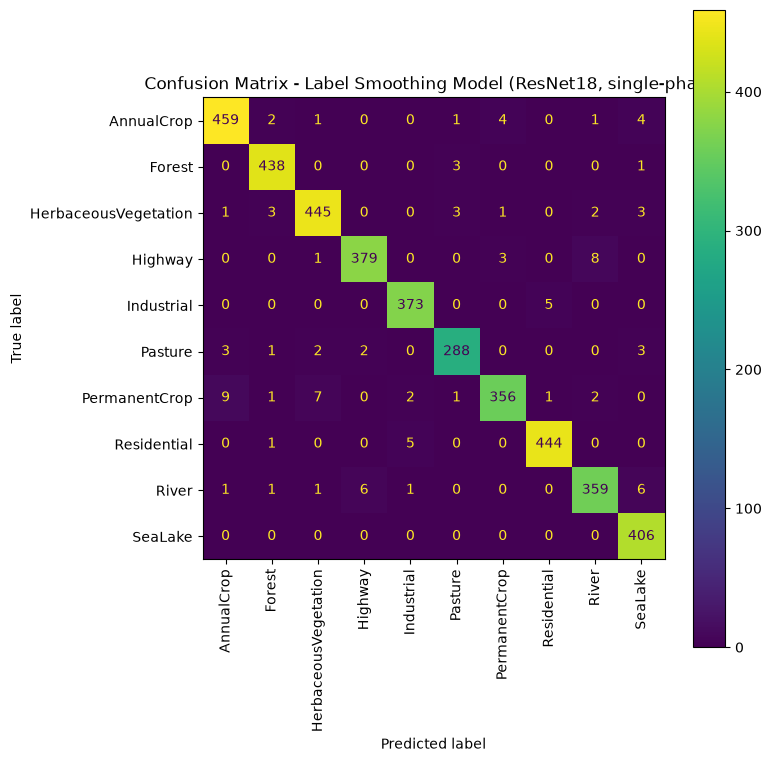

In [11]:
# Confusion matrix of the model freeze-first (ResNet18)
all_preds, all_labels = evaluate_classifier(model_resnet18, test_loader, device, classes, verbose=True)
draw_confusion_matrix(all_labels, all_preds, classes, "Confusion Matrix - Freeze-first Model (ResNet18)")

# Confusion matrix of the model baseline (ResNet18, single-phase)
all_preds_baseline, all_labels_baseline = evaluate_classifier(model_baseline, test_loader, device, classes, verbose=True)
draw_confusion_matrix(all_labels_baseline, all_preds_baseline, classes, "Confusion Matrix - Baseline Model (ResNet18, single-phase)")

# Confusion matrix of the model EfficientNet-B0 (freeze-first)
all_preds_efficientnet, all_labels_efficientnet = evaluate_classifier(model_efficientnet, test_loader, device, classes, verbose=True)
draw_confusion_matrix(all_labels_efficientnet, all_preds_efficientnet, classes, "Confusion Matrix - EfficientNet-B0 (freeze-first)")

# Confusion matrix of the model with label smoothing (ResNet18, single-phase)
all_preds_label_smoothing, all_labels_label_smoothing = evaluate_classifier(model_label_smoothing, test_loader, device, classes, verbose=True)
draw_confusion_matrix(all_labels_label_smoothing, all_preds_label_smoothing, classes, "Confusion Matrix - Label Smoothing Model (ResNet18, single-phase)")

#### Evaluation of the trained model on the "test" split set [all network fine tuned]




## 6/ Save the trained weight in a binary to reuse it

In [ ]:
CHECKPOINT_DIR = Path.cwd().parent / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
# model.state_dict() -> retourne un dictionnaire Python contenant tous les poids appris du réseau (les tenseurs de model.fc, des couches convolutives ResNet18, etc.), sans l'architecture elle-même.
torch.save(model_baseline.state_dict(), CHECKPOINT_DIR / "resnet18_eurosat.pth")
print(f"Saved checkpoint to {CHECKPOINT_DIR / 'resnet18_eurosat.pth'}")

torch.save(model_resnet18.state_dict(), CHECKPOINT_DIR / "resnet18_eurosat_2_train_phases.pth")
print(f"Saved checkpoint to {CHECKPOINT_DIR / 'resnet18_eurosat_2_train_phases.pth'}")

torch.save(model_label_smoothing.state_dict(), CHECKPOINT_DIR / "resnet18_eurosat_label_smoothing.pth")
print(f"Saved checkpoint to {CHECKPOINT_DIR / 'resnet18_eurosat_label_smoothing.pth'}")

torch.save(model_efficientnet.state_dict(), CHECKPOINT_DIR / "model_efficientnet.pth")
print(f"Saved checkpoint to {CHECKPOINT_DIR / 'model_efficientnet.pth'}")       